In [1]:
import json
import os
import warnings
from itertools import combinations
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak")

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.collections import PatchCollection
from matplotlib.patches import Patch, Polygon
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import RobustScaler, StandardScaler

RANDOM_STATE = 42

cwd = Path.cwd().resolve()
ROOT = cwd.parent if (cwd.parent / "commuting-data").exists() else cwd
if not (ROOT / "commuting-data").exists():
    raise FileNotFoundError("Run from the repository root or cluster_lsoa directory")

RAW_CSV = ROOT / "data" / "features.csv"
COMMUTE_CSV = ROOT / "commuting-data" / "data_swindon_with_lsoa_commute.csv"
GEOJSON = ROOT / "data preprocessing+EDA" / "Shi" / "LSOA_boundaries.geojson"
FIGURES = ROOT / "cluster_lsoa" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans", "Liberation Sans"],
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "font.size": 7,
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.linewidth": 0.8,
    "legend.frameon": False,
})

PALETTE = ["#5B7FCA", "#82ADD3", "#55A58F", "#D99B4E", "#B85B5B"]

def save_figure(fig, stem, dpi=300):
    paths = []
    for ext in ("svg", "png"):
        path = FIGURES / f"{stem}.{ext}"
        fig.savefig(path, bbox_inches="tight", facecolor="white", dpi=dpi)
        paths.append(path)
    return paths

In [2]:
raw = pd.read_csv(RAW_CSV, low_memory=False)
commute = pd.read_csv(COMMUTE_CSV, low_memory=False)
raw = raw.loc[raw["LSOA21CD"].isin(commute["LSOA21CD"])].copy()

assert len(raw) == len(commute) == 137
assert raw["LSOA21CD"].is_unique and commute["LSOA21CD"].is_unique

level4 = next(c for c in raw.columns if c.startswith("Level 4 qualifications or above"))
noqual = next(c for c in raw.columns if c.startswith("No qualifications"))

raw_columns = [
    "LSOA21CD", "LSOA21NM", "MSOA21CD", level4, noqual,
    "Education_decile", "IMD_decile", "Income_decile", "Employment_decile",
    "AdultSkills_decile", "Pct_Working_Age", "total_employees",
    "employment_rate_per_pop", "full_to_part_ratio",
    "LU_pct_micro_2025_msoa", "LU_pct_large_2025_msoa",
    "LU_diversity_1-HHI_2025", "turnover_diversity_1-HHI_2025_msoa",
    "enterprises_per_1k_residents_2025", "share_enterprises_kibs_2025_msoa",
    "share_enterprises_foundational_2025_msoa", "share_enterprises_industrial_2025_msoa",
    "Average download speed (Mbit/s)", "bus_stop_density", "dist_to_primary_m",
    "VOA_total_RV_million_2023", "VOA_median_RV_thousand_2023",
]
commute_columns = [
    "LSOA21CD", "log_total_GVA_2023", "log_voa_rv_2023",
    "rv_per_working_age", "rv_per_employee", "sme_density",
    "qualification_index", "firm_size_diversity", "sme_qual_interaction",
    "employment_quality", "modern_sector_leverage", "asset_growth_diversity",
    "lsoa_home_or_no_fixed_share", "lsoa_same_lsoa_work_share",
    "lsoa_out_commute_share", "lsoa_in_commute_share", "lsoa_local_worker_share",
    "lsoa_outbound_from_swindon_share", "lsoa_inbound_to_swindon_share",
]

df = raw[raw_columns].merge(
    commute[commute_columns], on="LSOA21CD", how="inner", validate="one_to_one",
    suffixes=("", "_commute"),
)

df = df.rename(columns={
    level4: "level4_pct", noqual: "noqual_pct",
    "Education_decile": "education_decile", "IMD_decile": "imd_decile",
    "Income_decile": "income_decile", "Employment_decile": "employment_decile",
    "AdultSkills_decile": "adultskills_decile", "Pct_Working_Age": "working_age_pct",
    "total_employees": "total_employees", "employment_rate_per_pop": "employment_rate",
    "full_to_part_ratio": "full_to_part_ratio",
    "LU_pct_micro_2025_msoa": "micro_share", "LU_pct_large_2025_msoa": "large_share",
    "LU_diversity_1-HHI_2025": "industry_diversity",
    "turnover_diversity_1-HHI_2025_msoa": "turnover_diversity",
    "enterprises_per_1k_residents_2025": "enterprise_density",
    "share_enterprises_kibs_2025_msoa": "kibs_share",
    "share_enterprises_foundational_2025_msoa": "foundational_share",
    "share_enterprises_industrial_2025_msoa": "industrial_share",
    "Average download speed (Mbit/s)": "download_speed",
    "bus_stop_density": "bus_stop_density", "dist_to_primary_m": "road_distance",
    "log_total_GVA_2023": "log_gva",
    "lsoa_home_or_no_fixed_share": "home_nofixed_share",
    "lsoa_same_lsoa_work_share": "same_lsoa_share",
    "lsoa_out_commute_share": "out_commute_share",
    "lsoa_in_commute_share": "in_commute_share",
    "lsoa_local_worker_share": "local_worker_share",
    "lsoa_outbound_from_swindon_share": "external_out_share",
    "lsoa_inbound_to_swindon_share": "external_in_share",
})

for col in df.columns.difference(["LSOA21CD", "LSOA21NM", "MSOA21CD"]):
    df[col] = pd.to_numeric(df[col], errors="coerce")

for src, dst in [
    ("rv_per_working_age", "log_rv_per_working_age"),
    ("rv_per_employee", "log_rv_per_employee"),
    ("total_employees", "log_employees"),
    ("bus_stop_density", "log_bus_density"),
    ("road_distance", "log_road_distance"),
]:
    df[dst] = np.log1p(df[src].clip(lower=0))

audit = pd.DataFrame({
    "source": ["Raw feature master", "Prepared LSOA commute table", "Merged Swindon analysis"],
    "rows": [len(raw), len(commute), len(df)],
    "unique_LSOA": [raw.LSOA21CD.nunique(), commute.LSOA21CD.nunique(), df.LSOA21CD.nunique()],
    "unique_MSOA": [raw.MSOA21CD.nunique(), commute.MSOA21CD.nunique(), df.MSOA21CD.nunique()],
})
display(audit)

voa_audit = df[["VOA_total_RV_million_2023", "VOA_median_RV_thousand_2023"]].describe().T
display(voa_audit[["count", "mean", "std", "min", "50%", "max"]])

,source,rows,unique_LSOA,unique_MSOA
0,Raw feature master,137,137,27
1,Prepared LSOA commute table,137,137,27
2,Merged Swindon analysis,137,137,27


,count,mean,std,min,50%,max
VOA_total_RV_million_2023,131.0,1.739977e+06,3.153775e+06,3.122326e+04,4.880067e+05,19141245.35
VOA_median_RV_thousand_2023,131.0,3.309284e+07,1.244059e+06,3.122326e+07,3.294753e+07,40001324.78


In [3]:
DOMAINS = {
    "asset": ["log_voa_rv_2023", "log_rv_per_working_age", "log_rv_per_employee"],
    "skills": ["level4_pct", "noqual_pct", "education_decile"],
    "labour": ["log_employees", "employment_rate", "full_to_part_ratio"],
    "commute": ["home_nofixed_share", "same_lsoa_share", "in_commute_share", "external_out_share", "external_in_share"],
    "business": ["micro_share", "large_share", "industry_diversity", "turnover_diversity"],
    "deprivation": ["imd_decile", "income_decile", "employment_decile"],
    "access": ["log_bus_density", "log_road_distance", "download_speed"],
    "sectors": ["sme_density", "kibs_share", "foundational_share", "industrial_share"],
}

FEATURE_SETS = {
    "asset + skills + labour": DOMAINS["asset"] + DOMAINS["skills"] + DOMAINS["labour"],
    "skills + labour + commute": DOMAINS["skills"] + DOMAINS["labour"] + DOMAINS["commute"],
    "asset + skills + labour + commute + business": (
        DOMAINS["asset"] + DOMAINS["skills"] + DOMAINS["labour"] + DOMAINS["commute"] + DOMAINS["business"]
    ),
    "skills + deprivation + access": DOMAINS["skills"] + DOMAINS["deprivation"] + DOMAINS["access"],
    "asset + labour + access + commute + business": (
        DOMAINS["asset"] + DOMAINS["labour"] + DOMAINS["access"] + DOMAINS["commute"] + DOMAINS["business"]
    ),
    "enterprise + commute": DOMAINS["business"] + DOMAINS["sectors"] + DOMAINS["commute"],
    "balanced LSOA": [
        "log_voa_rv_2023", "log_rv_per_working_age", "level4_pct", "noqual_pct",
        "imd_decile", "log_employees", "employment_rate", "download_speed",
        "log_bus_density", "log_road_distance", "home_nofixed_share",
        "in_commute_share", "external_out_share",
    ],
    "previous-style engineered + commute": [
        "log_voa_rv_2023", "rv_per_working_age", "sme_density", "qualification_index",
        "firm_size_diversity", "rv_per_employee", "sme_qual_interaction",
        "employment_quality", "modern_sector_leverage", "asset_growth_diversity",
        "out_commute_share", "same_lsoa_share", "home_nofixed_share",
        "in_commute_share", "local_worker_share",
    ],
}

HELD_OUT = [
    "log_gva", "imd_decile", "adultskills_decile", "sme_density",
    "enterprise_density", "industrial_share", "download_speed", "bus_stop_density",
]

def prepare_matrix(data, columns, scaler="standard"):
    x = data[columns].replace([np.inf, -np.inf], np.nan)
    x = pd.DataFrame(SimpleImputer(strategy="median").fit_transform(x), columns=columns)
    for col in columns:
        lo, hi = x[col].quantile([0.01, 0.99])
        x[col] = x[col].clip(lo, hi)
    transformer = StandardScaler() if scaler == "standard" else RobustScaler()
    return transformer.fit_transform(x), x

def eta_squared(values, labels):
    values = np.asarray(values, float)
    ok = np.isfinite(values)
    values, labels = values[ok], np.asarray(labels)[ok]
    grand = values.mean()
    ss_between = sum((values[labels == g].size) * (values[labels == g].mean() - grand) ** 2 for g in np.unique(labels))
    ss_total = np.sum((values - grand) ** 2)
    return float(ss_between / ss_total) if ss_total else 0.0

def density_overlap(values, labels):
    values = np.asarray(values, float)
    ok = np.isfinite(values)
    values, labels = values[ok], np.asarray(labels)[ok]
    grid = np.linspace(np.percentile(values, 0.5), np.percentile(values, 99.5), 512)
    densities = {}
    for g in np.unique(labels):
        arr = values[labels == g]
        if len(arr) >= 3 and np.std(arr) > 0:
            z = stats.gaussian_kde(arr)(grid)
        else:
            z = np.zeros_like(grid)
            z[np.argmin(abs(grid - np.mean(arr)))] = 1
        z = z / np.trapz(z, grid)
        densities[g] = z
    overlaps = [np.trapz(np.minimum(densities[a], densities[b]), grid) for a, b in combinations(densities, 2)]
    return float(np.mean(overlaps)), float(np.max(overlaps))

def evaluate_solution(columns, scaler, k):
    x, _ = prepare_matrix(df, columns, scaler)
    labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=50).fit_predict(x)
    stability = []
    for seed in range(8):
        alt = KMeans(n_clusters=k, random_state=1000 + seed, n_init=5).fit_predict(x)
        stability.append(adjusted_rand_score(labels, alt))
    held = [v for v in HELD_OUT if v not in columns]
    held_eta = [eta_squared(df[v], labels) for v in held]
    held_ovl = [density_overlap(df[v], labels)[0] for v in held]
    counts = np.bincount(labels, minlength=k)
    return {
        "silhouette": silhouette_score(x, labels),
        "davies_bouldin": davies_bouldin_score(x, labels),
        "stability_ari": np.mean(stability),
        "smallest_cluster_n": counts.min(),
        "largest_cluster_n": counts.max(),
        "mean_heldout_eta2": np.mean(held_eta),
        "mean_heldout_overlap": np.mean(held_ovl),
        "gva_eta2": eta_squared(df["log_gva"], labels),
        "gva_overlap": density_overlap(df["log_gva"], labels)[0],
    }

In [4]:
search_rows = []
for family, columns in FEATURE_SETS.items():
    for scaler in ("standard", "robust"):
        for k in (4, 5, 6):
            row = {"feature_family": family, "scaler": scaler, "k": k, "n_features": len(columns)}
            row.update(evaluate_solution(columns, scaler, k))
            search_rows.append(row)

search = pd.DataFrame(search_rows)
eligible = search[(search.smallest_cluster_n >= 8) & (search.stability_ari >= 0.90)].copy()

for col in ["silhouette", "stability_ari", "mean_heldout_eta2"]:
    eligible[col + "_rank"] = eligible[col].rank(pct=True)
for col in ["davies_bouldin", "mean_heldout_overlap"]:
    eligible[col + "_rank"] = eligible[col].rank(pct=True, ascending=False)
eligible["composite"] = (
    0.35 * eligible.silhouette_rank
    + 0.20 * eligible.davies_bouldin_rank
    + 0.20 * eligible.stability_ari_rank
    + 0.15 * eligible.mean_heldout_eta2_rank
    + 0.10 * eligible.mean_heldout_overlap_rank
)

display(eligible.sort_values(["composite", "silhouette"], ascending=False)[[
    "feature_family", "scaler", "k", "n_features", "silhouette", "davies_bouldin",
    "stability_ari", "smallest_cluster_n", "largest_cluster_n",
    "mean_heldout_eta2", "mean_heldout_overlap", "gva_eta2", "gva_overlap", "composite",
]].head(12).style.format(precision=3))

,feature_family,scaler,k,n_features,silhouette,davies_bouldin,stability_ari,smallest_cluster_n,largest_cluster_n,mean_heldout_eta2,mean_heldout_overlap,gva_eta2,gva_overlap,composite
0,asset + skills + labour,standard,4,9,0.241,1.295,0.985,21,43,0.278,0.664,0.511,0.512,0.713
6,skills + labour + commute,standard,4,11,0.195,1.541,1.000,23,43,0.344,0.595,0.492,0.581,0.681
21,skills + deprivation + access,robust,4,9,0.316,1.142,0.980,13,58,0.176,0.726,0.043,0.795,0.656
12,asset + skills + labour + commute + business,standard,4,18,0.201,1.504,0.986,21,55,0.301,0.630,0.469,0.506,0.656
30,enterprise + commute,standard,4,13,0.236,1.524,0.931,22,43,0.259,0.655,0.312,0.599,0.512
36,balanced LSOA,standard,4,13,0.212,1.569,0.905,15,56,0.318,0.596,0.454,0.583,0.494
13,asset + skills + labour + commute + business,standard,5,18,0.192,1.554,0.985,22,31,0.342,0.621,0.605,0.496,0.494
24,asset + labour + access + commute + business,standard,4,18,0.180,1.725,0.982,23,60,0.279,0.642,0.583,0.467,0.294


,k,silhouette,davies_bouldin,stability_ari,smallest_cluster_n,largest_cluster_n,mean_heldout_eta2,mean_heldout_overlap,gva_eta2,gva_overlap
12,4,0.201,1.504,0.986,21,55,0.301,0.630,0.469,0.506
13,5,0.192,1.554,0.985,22,31,0.342,0.621,0.605,0.496
14,6,0.193,1.519,0.808,3,32,0.359,0.567,0.551,0.402


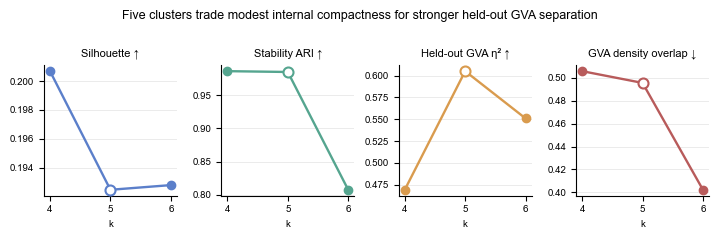

In [5]:
FINAL_FAMILY = "asset + skills + labour + commute + business"
FINAL_SCALER = "standard"
FINAL_K = 5

family_tradeoff = search[(search.feature_family == FINAL_FAMILY) & (search.scaler == FINAL_SCALER)].copy()
display(family_tradeoff[[
    "k", "silhouette", "davies_bouldin", "stability_ari", "smallest_cluster_n",
    "largest_cluster_n", "mean_heldout_eta2", "mean_heldout_overlap", "gva_eta2", "gva_overlap",
]].style.format(precision=3))

selected_row = family_tradeoff[family_tradeoff.k == FINAL_K].iloc[0]
assert selected_row.smallest_cluster_n >= 8 and selected_row.stability_ari >= 0.90

fig, axes = plt.subplots(1, 4, figsize=(7.2, 2.25))
metrics_to_plot = [
    ("silhouette", "Silhouette ↑", "#5B7FCA"),
    ("stability_ari", "Stability ARI ↑", "#55A58F"),
    ("gva_eta2", "Held-out GVA η² ↑", "#D99B4E"),
    ("gva_overlap", "GVA density overlap ↓", "#B85B5B"),
]
for ax, (metric, title, color) in zip(axes, metrics_to_plot):
    ax.plot(family_tradeoff.k, family_tradeoff[metric], marker="o", lw=1.7, color=color)
    ax.scatter([FINAL_K], [selected_row[metric]], s=52, facecolor="white", edgecolor=color, lw=1.5, zorder=5)
    ax.set_xticks([4, 5, 6])
    ax.set_xlabel("k")
    ax.set_title(title, fontsize=8)
    ax.grid(axis="y", color="#E8E8E8", lw=0.6)
fig.suptitle("Five clusters trade modest internal compactness for stronger held-out GVA separation", fontsize=9, y=1.02)
fig.tight_layout()
save_figure(fig, "fig4_feature_family_search")
plt.show()

In [6]:
FINAL_FEATURES = FEATURE_SETS[FINAL_FAMILY]
X_scaled, X_clean = prepare_matrix(df, FINAL_FEATURES, FINAL_SCALER)
raw_labels = KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=100).fit_predict(X_scaled)

raw_order = df.assign(raw_cluster=raw_labels).groupby("raw_cluster")["log_gva"].mean().sort_values().index
remap = {raw_id: i for i, raw_id in enumerate(raw_order)}
labels = np.array([remap[x] for x in raw_labels])

clustered = df.copy()
clustered["cluster"] = labels
clustered["cluster_id"] = clustered["cluster"].map(lambda x: f"C{x + 1}")
CLUSTER_NAMES = {
    0: "Skilled residential",
    1: "Lower-asset residential",
    2: "Local mixed economy",
    3: "Skilled enterprise corridor",
    4: "Employment hub",
}
clustered["cluster_name"] = clustered.cluster.map(CLUSTER_NAMES)
clustered["cluster_label"] = clustered.cluster_id + " · " + clustered.cluster_name
COLORS = {i: PALETTE[i] for i in range(FINAL_K)}

summary = clustered.groupby(["cluster", "cluster_label"]).agg(
    n_lsoa=("LSOA21CD", "size"), mean_log_gva=("log_gva", "mean"),
    level4_pct=("level4_pct", "mean"), imd_decile=("imd_decile", "mean"),
    employment_rate=("employment_rate", "mean"), sme_density=("sme_density", "mean"),
    home_nofixed_share=("home_nofixed_share", "mean"),
    external_out_share=("external_out_share", "mean"),
).reset_index()
display(summary.style.format({
    "mean_log_gva": "{:.2f}", "level4_pct": "{:.1f}", "imd_decile": "{:.1f}",
    "employment_rate": "{:.2f}", "sme_density": "{:.1f}",
    "home_nofixed_share": "{:.1%}", "external_out_share": "{:.1%}",
}))

,cluster,cluster_label,n_lsoa,mean_log_gva,level4_pct,imd_decile,employment_rate,sme_density,home_nofixed_share,external_out_share
0,0,C1 · Skilled residential,30,2.51,25.6,8.5,0.09,148.8,49.5%,28.8%
1,1,C2 · Lower-asset residential,31,2.56,15.1,4.5,0.09,96.6,38.0%,22.0%
2,2,C3 · Local mixed economy,25,3.04,17.4,4.6,0.21,207.8,35.6%,21.1%
3,3,C4 · Skilled enterprise corridor,29,3.84,26.1,7.2,0.33,252.6,50.5%,29.6%
4,4,C5 · Employment hub,22,5.35,22.4,6.4,1.90,293.2,43.7%,24.8%


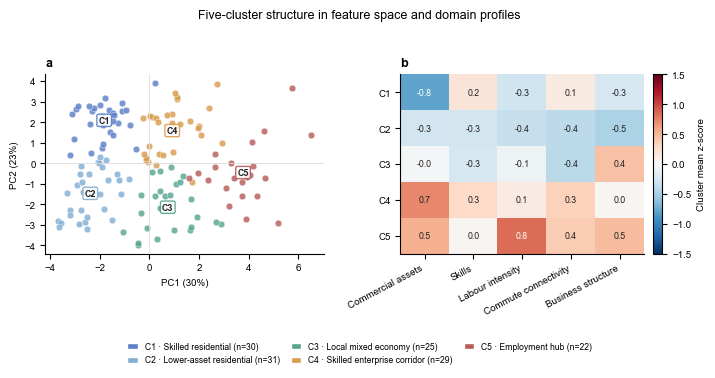

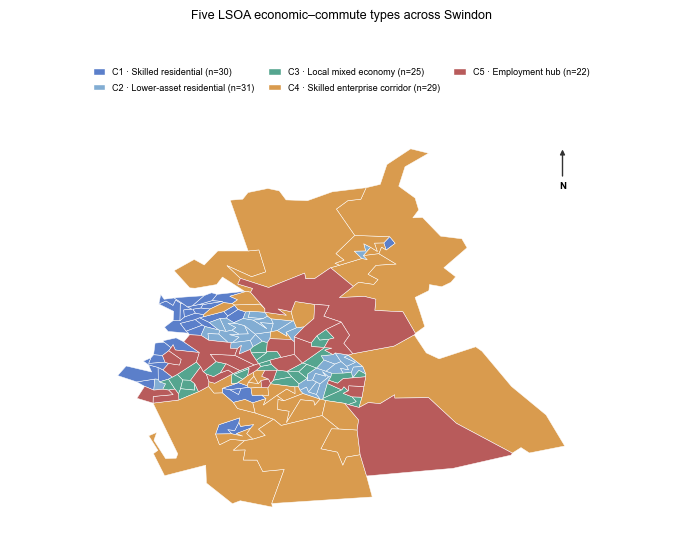

In [7]:
feature_z = pd.DataFrame(StandardScaler().fit_transform(X_clean), columns=FINAL_FEATURES, index=clustered.index)
domain_columns = {
    "Commercial assets": DOMAINS["asset"],
    "Skills": DOMAINS["skills"],
    "Labour intensity": DOMAINS["labour"],
    "Commute connectivity": DOMAINS["commute"],
    "Business structure": DOMAINS["business"],
}
domain_scores = pd.DataFrame({name: feature_z[cols].mean(axis=1) for name, cols in domain_columns.items()})
domain_scores["cluster"] = clustered.cluster
domain_profile = domain_scores.groupby("cluster").mean()

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
clustered["PC1"], clustered["PC2"] = coords[:, 0], coords[:, 1]

with open(GEOJSON, encoding="utf-8") as handle:
    geo = json.load(handle)
geo_codes = {feature["properties"].get("LSOA21CD") for feature in geo["features"]}
assert set(clustered.LSOA21CD).issubset(geo_codes)

def polygon_rings(geometry):
    if geometry["type"] == "Polygon":
        return [geometry["coordinates"]]
    if geometry["type"] == "MultiPolygon":
        return geometry["coordinates"]
    return []

def draw_map(ax):
    by_lsoa = clustered.set_index("LSOA21CD")["cluster"].to_dict()
    patches = {c: [] for c in range(FINAL_K)}
    for feature in geo["features"]:
        code = feature["properties"].get("LSOA21CD")
        if code not in by_lsoa:
            continue
        c = int(by_lsoa[code])
        for polygon in polygon_rings(feature["geometry"]):
            if polygon and polygon[0]:
                patches[c].append(Polygon(np.asarray(polygon[0]), closed=True))
    for c, parts in patches.items():
        ax.add_collection(PatchCollection(parts, facecolor=COLORS[c], edgecolor="white", linewidth=0.35))
    ax.autoscale_view()
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.annotate(
        "N", xy=(0.95, 0.96), xytext=(0.95, 0.86), xycoords="axes fraction",
        ha="center", va="center", fontweight="bold",
        arrowprops=dict(arrowstyle="-|>", lw=1, color="#333333"),
    )

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.65), gridspec_kw={"width_ratios": [1.05, 1.0]})
ax_pca, ax_heat = axes

for c in range(FINAL_K):
    part = clustered[clustered.cluster == c]
    ax_pca.scatter(
        part.PC1, part.PC2, s=23, alpha=0.82, color=COLORS[c],
        edgecolor="white", lw=0.35,
    )
    centre = part[["PC1", "PC2"]].mean()
    ax_pca.text(
        centre.PC1, centre.PC2, f"C{c+1}", ha="center", va="center",
        fontsize=6.5, fontweight="bold", color="#202020",
        bbox=dict(boxstyle="round,pad=0.18", facecolor="white", edgecolor=COLORS[c], alpha=0.9),
    )
ax_pca.axhline(0, color="#DDDDDD", lw=0.6)
ax_pca.axvline(0, color="#DDDDDD", lw=0.6)
ax_pca.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%})")
ax_pca.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%})")
ax_pca.set_title("a", loc="left", fontweight="bold", fontsize=9)

im = ax_heat.imshow(domain_profile, cmap="RdBu_r", vmin=-1.5, vmax=1.5, aspect="auto")
ax_heat.set_xticks(range(domain_profile.shape[1]), domain_profile.columns, rotation=28, ha="right")
ax_heat.set_yticks(range(FINAL_K), [f"C{i+1}" for i in range(FINAL_K)])
for i in range(FINAL_K):
    for j in range(domain_profile.shape[1]):
        value = domain_profile.iloc[i, j]
        ax_heat.text(
            j, i, f"{value:.1f}", ha="center", va="center", fontsize=6.3,
            color="white" if abs(value) > 0.75 else "#222222",
        )
ax_heat.set_title("b", loc="left", fontweight="bold", fontsize=9)
cbar = fig.colorbar(im, ax=ax_heat, fraction=0.046, pad=0.035)
cbar.set_label("Cluster mean z-score")

legend_handles = [
    Patch(facecolor=COLORS[c], edgecolor="white", label=f"C{c+1} · {CLUSTER_NAMES[c]} (n={(clustered.cluster == c).sum()})")
    for c in range(FINAL_K)
]
fig.legend(
    handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.005),
    ncol=3, fontsize=6.2, frameon=False, handlelength=1.2, columnspacing=1.3,
)
fig.suptitle("Five-cluster structure in feature space and domain profiles", fontsize=9, y=0.99)
fig.tight_layout(rect=(0, 0.12, 1, 0.95), w_pad=2.2)
save_figure(fig, "fig2_five_cluster_typology")
plt.show()

fig = plt.figure(figsize=(7.2, 5.4))
gs = fig.add_gridspec(2, 1, height_ratios=[0.19, 0.81], hspace=0.02)
ax_legend = fig.add_subplot(gs[0])
ax_map = fig.add_subplot(gs[1])
ax_legend.axis("off")
ax_legend.legend(
    handles=legend_handles, loc="center", ncol=3, fontsize=6.5,
    frameon=False, handlelength=1.4, columnspacing=1.5, labelspacing=0.7,
)
draw_map(ax_map)
fig.suptitle("Five LSOA economic–commute types across Swindon", fontsize=9, y=0.985)
fig.subplots_adjust(left=0.04, right=0.96, top=0.94, bottom=0.03)
save_figure(fig, "fig3_five_cluster_map")
plt.show()

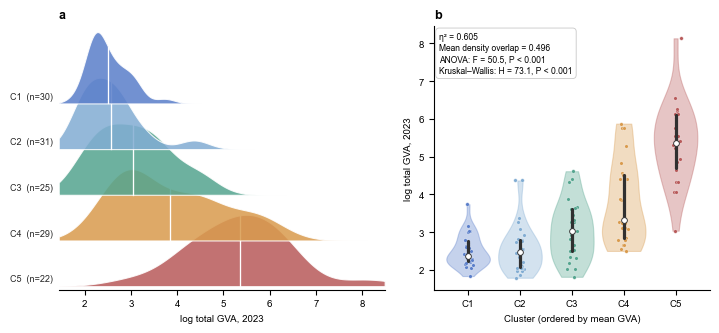

In [8]:
import matplotlib.transforms as mtransforms

gva_groups_for_figure = [
    clustered.loc[clustered.cluster == c, "log_gva"].dropna().to_numpy()
    for c in range(FINAL_K)
]
gva_eta_for_figure = eta_squared(clustered.log_gva, clustered.cluster)
gva_f_for_figure, gva_p_for_figure = stats.f_oneway(*gva_groups_for_figure)
gva_h_for_figure, gva_pk_for_figure = stats.kruskal(*gva_groups_for_figure)
gva_overlap_for_figure, gva_max_overlap_for_figure = density_overlap(clustered.log_gva, clustered.cluster)

def p_text(p):
    return "P < 0.001" if p < 0.001 else f"P = {p:.3f}"

fig, (ax_ridge, ax_violin) = plt.subplots(
    1, 2, figsize=(7.2, 3.35), gridspec_kw={"width_ratios": [1.18, 1.0]}
)

xs = np.linspace(clustered.log_gva.min() - 0.35, clustered.log_gva.max() + 0.35, 450)
label_transform = mtransforms.blended_transform_factory(ax_ridge.transAxes, ax_ridge.transData)
ridge_gap = 0.64
for row, c in enumerate(range(FINAL_K)):
    values = gva_groups_for_figure[c]
    kde = stats.gaussian_kde(values)
    density = kde(xs)
    density = density / density.max()
    base = (FINAL_K - 1 - row) * ridge_gap
    ax_ridge.fill_between(
        xs, base, base + density, color=COLORS[c], alpha=0.86,
        lw=0.8, edgecolor="white", zorder=2 * (FINAL_K - row),
    )
    mean_height = float(kde(values.mean())[0]) / float(kde(xs).max())
    ax_ridge.plot(
        [values.mean(), values.mean()], [base, base + mean_height],
        color="white", lw=0.95, zorder=2 * (FINAL_K - row) + 1,
    )
    ax_ridge.text(
        -0.018, base + 0.04, f"C{c+1}  (n={len(values)})",
        transform=label_transform, va="bottom", ha="right", fontsize=6.5, color="#262626",
    )
ax_ridge.set_xlim(xs[0], xs[-1])
ax_ridge.set_ylim(-0.05, (FINAL_K - 1) * ridge_gap + 1.08)
ax_ridge.set_yticks([])
ax_ridge.set_xlabel("log total GVA, 2023")
ax_ridge.spines["left"].set_visible(False)
ax_ridge.set_title("a", loc="left", fontweight="bold", fontsize=9)

positions = np.arange(FINAL_K)
parts = ax_violin.violinplot(
    gva_groups_for_figure, positions=positions, showextrema=False, widths=0.84,
)
for body, c in zip(parts["bodies"], range(FINAL_K)):
    body.set_facecolor(COLORS[c])
    body.set_edgecolor(COLORS[c])
    body.set_alpha(0.35)
    body.set_linewidth(0.8)
for c, values in enumerate(gva_groups_for_figure):
    jitter = np.random.default_rng(100 + c).normal(0, 0.045, len(values))
    ax_violin.scatter(
        c + jitter, values, s=7, color=COLORS[c], edgecolor="white",
        linewidth=0.25, zorder=3,
    )
    q1, median, q3 = np.percentile(values, [25, 50, 75])
    ax_violin.plot([c, c], [q1, q3], color="#303030", lw=2.3, solid_capstyle="round", zorder=4)
    ax_violin.scatter(c, median, s=17, color="white", edgecolor="#303030", linewidth=0.65, zorder=5)
ax_violin.set_xticks(positions, [f"C{i+1}" for i in range(FINAL_K)])
ax_violin.set_xlabel("Cluster (ordered by mean GVA)")
ax_violin.set_ylabel("log total GVA, 2023")
ax_violin.set_title("b", loc="left", fontweight="bold", fontsize=9)
statistics_text = (
    f"η² = {gva_eta_for_figure:.3f}\n"
    f"Mean density overlap = {gva_overlap_for_figure:.3f}\n"
    f"ANOVA: F = {gva_f_for_figure:.1f}, {p_text(gva_p_for_figure)}\n"
    f"Kruskal–Wallis: H = {gva_h_for_figure:.1f}, {p_text(gva_pk_for_figure)}"
)
ax_violin.text(
    0.02, 0.98, statistics_text, transform=ax_violin.transAxes,
    va="top", ha="left", fontsize=6.1, linespacing=1.35,
    bbox=dict(boxstyle="round,pad=0.42", facecolor="white", edgecolor="#C8C8C8", lw=0.6),
)

fig.tight_layout(w_pad=2.0)
save_figure(fig, "fig1_cluster_gva_separation")
plt.show()

In [9]:
gva_groups = [clustered.loc[clustered.cluster == c, "log_gva"].to_numpy() for c in range(FINAL_K)]
f_stat, p_anova = stats.f_oneway(*gva_groups)
lev_stat, p_levene = stats.levene(*gva_groups, center="median")
h_stat, p_kruskal = stats.kruskal(*gva_groups)
eta2_gva = eta_squared(clustered.log_gva, clustered.cluster)

grand = clustered.log_gva.mean()
ss_between = sum(len(g) * (g.mean() - grand) ** 2 for g in gva_groups)
ss_within = sum(np.sum((g - g.mean()) ** 2) for g in gva_groups)
df_between, df_within = FINAL_K - 1, len(clustered) - FINAL_K
ms_within = ss_within / df_within
omega2 = (ss_between - df_between * ms_within) / (ss_between + ss_within + ms_within)

omnibus = pd.DataFrame({
    "test": ["One-way ANOVA", "Levene (median)", "Kruskal–Wallis"],
    "statistic": [f_stat, lev_stat, h_stat],
    "p_value": [p_anova, p_levene, p_kruskal],
})
display(omnibus.style.format({"statistic": "{:.2f}", "p_value": "{:.3e}"}))

pair_rows = []
for a, b in combinations(range(FINAL_K), 2):
    stat, p = stats.ttest_ind(gva_groups[a], gva_groups[b], equal_var=False)
    pair_rows.append({"cluster_a": f"C{a+1}", "cluster_b": f"C{b+1}", "t": stat, "p_raw": p})
pairwise = pd.DataFrame(pair_rows).sort_values("p_raw").reset_index(drop=True)
m = len(pairwise)
pairwise["p_holm"] = np.maximum.accumulate((m - np.arange(m)) * pairwise.p_raw).clip(upper=1)
pairwise["significant_0.05"] = pairwise.p_holm < 0.05
display(pairwise.sort_values(["cluster_a", "cluster_b"]).style.format({"t": "{:.2f}", "p_raw": "{:.2e}", "p_holm": "{:.2e}"}))

,test,statistic,p_value
0,One-way ANOVA,50.54,9.726e-26
1,Levene (median),5.98,1.859e-04
2,Kruskal–Wallis,73.13,4.948e-15


,cluster_a,cluster_b,t,p_raw,p_holm,significant_0.05
9,C1,C2,-0.42,6.75e-01,6.75e-01,False
7,C1,C3,-3.10,3.76e-03,1.26e-02,True
3,C1,C4,-6.12,5.04e-07,3.53e-06,True
1,C1,C5,-11.75,8.39e-12,7.55e-11,True
8,C2,C3,-2.49,1.64e-02,3.29e-02,True
4,C2,C4,-5.46,2.08e-06,1.25e-05,True
0,C2,C5,-10.86,3.94e-12,3.94e-11,True
6,C3,C4,-3.10,3.14e-03,1.26e-02,True
2,C3,C5,-8.30,4.84e-10,3.88e-09,True
5,C4,C5,-4.89,1.26e-05,6.30e-05,True


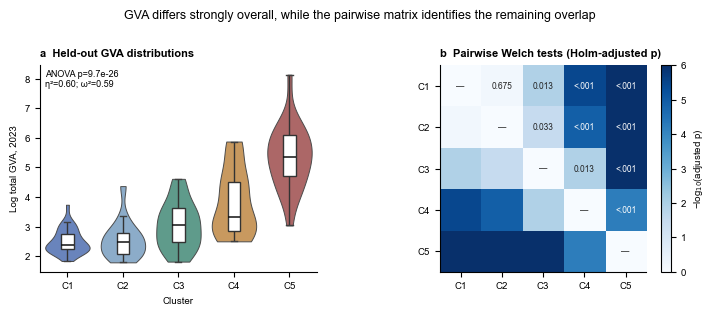

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0), gridspec_kw={"width_ratios": [1.05, 1.35]})

order = [f"C{i+1}" for i in range(FINAL_K)]
sns.violinplot(data=clustered, x="cluster_id", y="log_gva", hue="cluster_id", order=order,
               palette={f"C{i+1}": PALETTE[i] for i in range(FINAL_K)}, legend=False,
               inner=None, cut=0, linewidth=0.7, ax=axes[0])
sns.boxplot(data=clustered, x="cluster_id", y="log_gva", order=order, width=0.22, showfliers=False,
            boxprops={"facecolor": "white", "edgecolor": "#333333"}, whiskerprops={"color": "#333333"},
            medianprops={"color": "#111111", "linewidth": 1.1}, ax=axes[0])
axes[0].set_xlabel("Cluster"); axes[0].set_ylabel("Log total GVA, 2023")
axes[0].set_title("a  Held-out GVA distributions", loc="left", fontweight="bold", fontsize=8)
axes[0].text(0.02, 0.98, f"ANOVA p={p_anova:.1e}\nη²={eta2_gva:.2f}; ω²={omega2:.2f}",
             transform=axes[0].transAxes, va="top", fontsize=6.5)

matrix = np.ones((FINAL_K, FINAL_K))
for _, row in pairwise.iterrows():
    a = int(row.cluster_a[1:]) - 1; b = int(row.cluster_b[1:]) - 1
    matrix[a, b] = matrix[b, a] = row.p_holm
plot_matrix = -np.log10(np.clip(matrix, 1e-12, 1))
im = axes[1].imshow(plot_matrix, cmap="Blues", vmin=0, vmax=6)
axes[1].set_xticks(range(FINAL_K), order); axes[1].set_yticks(range(FINAL_K), order)
for i in range(FINAL_K):
    for j in range(FINAL_K):
        if i == j:
            text = "—"
        elif i < j:
            p = matrix[i, j]; text = "<.001" if p < .001 else f"{p:.3f}"
        else:
            text = ""
        axes[1].text(j, i, text, ha="center", va="center", fontsize=6,
                     color="white" if plot_matrix[i, j] > 3 else "#222222")
axes[1].set_title("b  Pairwise Welch tests (Holm-adjusted p)", loc="left", fontweight="bold", fontsize=8)
cbar = fig.colorbar(im, ax=axes[1], fraction=0.045, pad=0.04); cbar.set_label("−log$_{10}$(adjusted p)")

fig.suptitle("GVA differs strongly overall, while the pairwise matrix identifies the remaining overlap", fontsize=9, y=1.02)
fig.tight_layout()
save_figure(fig, "fig5_gva_validation")
plt.show()

In [11]:
final_cluster_labels = clustered[[
    "LSOA21CD", "LSOA21NM", "MSOA21CD", "cluster_name"
]].copy()
final_cluster_labels["label"] = clustered["cluster"].astype(int) + 1
final_cluster_labels = final_cluster_labels[[
    "LSOA21CD", "LSOA21NM", "MSOA21CD", "label", "cluster_name"
]].sort_values(["label", "LSOA21CD"]).reset_index(drop=True)

assert set(final_cluster_labels["label"]) == {1, 2, 3, 4, 5}
LABEL_CSV = ROOT / "cluster_lsoa" / "swindon_lsoa_cluster_labels_k5.csv"
final_cluster_labels.to_csv(LABEL_CSV, index=False, encoding="utf-8-sig")
